<a href="https://colab.research.google.com/github/ayushi771/tweet-detector/blob/main/tweetdetector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install transformers datasets accelerate optuna shap spacy wordcloud
!python -m spacy download en_core_web_sm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 87.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from wordcloud import WordCloud

import re
import spacy

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch

In [7]:
from google.colab import files
uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [8]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [9]:
train.shape

(7613, 5)

In [10]:
train.isnull().sum()

,0
id,0
keyword,61
location,2533
text,0
target,0


In [11]:
train['keyword'] = train['keyword'].fillna('unknown')
train['location'] = train['location'].fillna('unknown')

In [12]:
train.isnull().sum()

,0
id,0
keyword,0
location,0
text,0
target,0


In [13]:
train['target'].value_counts()

,count
target,
0,4342
1,3271


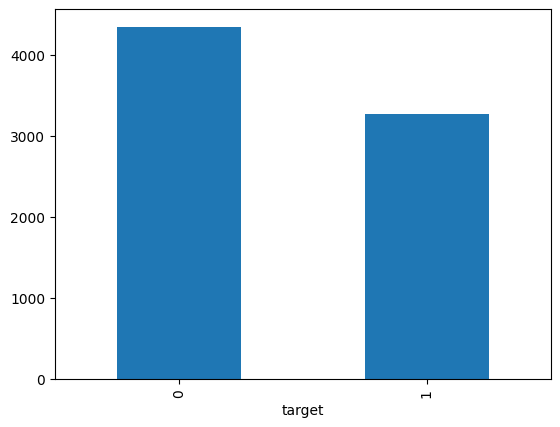

In [14]:
train['target'].value_counts().plot(kind='bar')
plt.show()

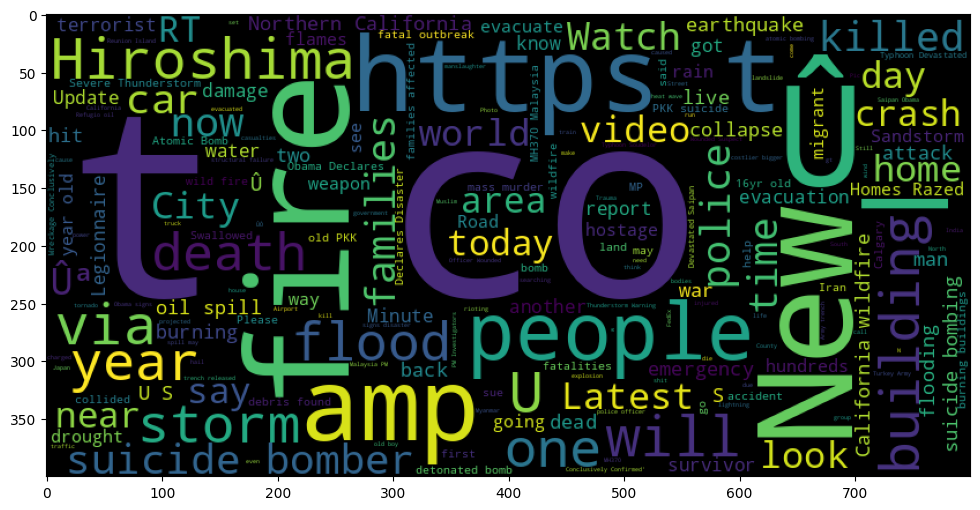

In [15]:
from wordcloud import WordCloud , STOPWORDS
stopwords = set(STOPWORDS)
disaster_text = " ".join(train[train['target']==1]['text'])
wordcloud = WordCloud(width=800 , height=400 , stopwords=stopwords ).generate(disaster_text)
plt.figure(figsize = (12 , 6))
plt.imshow(wordcloud)
plt.show()

In [16]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove URLs
    text = re.sub(r'http\S+', '', text)

    # remove HTML entities like &amp;
    text = re.sub(r'&\w+;', '', text)

    # remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # remove stopwords
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

train['clean_text'] = train['text'].apply(clean_text)
test['clean_text'] = test['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


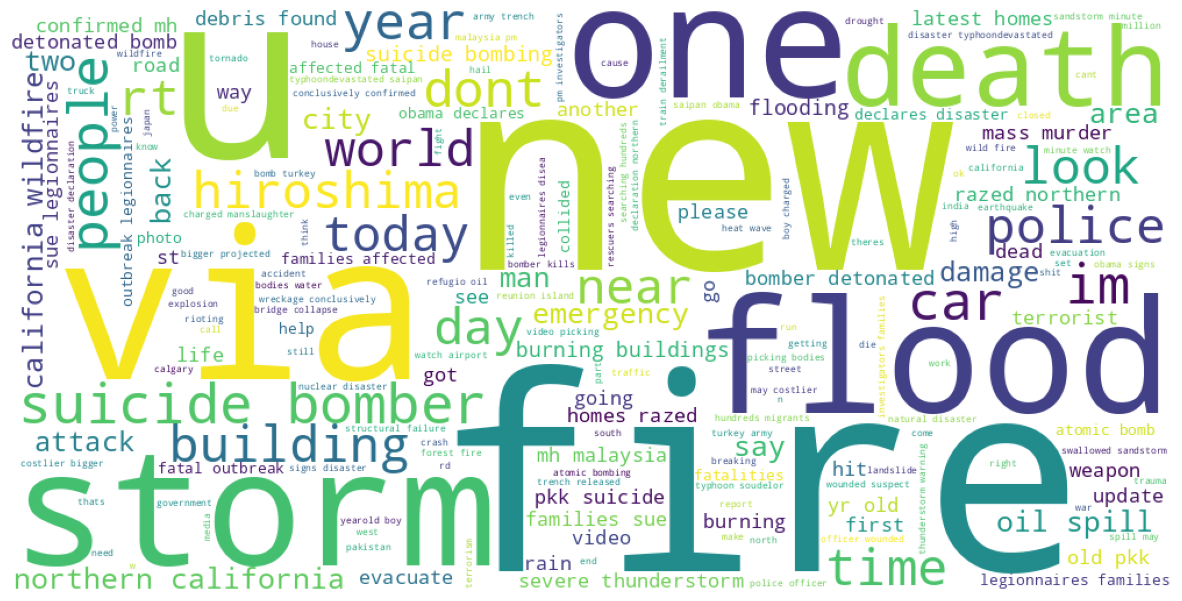

In [17]:
disaster_text = " ".join(
    train[train['target']==1]['clean_text']
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(disaster_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [18]:
train['tweet_length'] = train['text'].apply(len)

In [19]:
train['word_count'] = train['text'].apply(
    lambda x:len(x.split())
)

In [20]:
train['caps_count'] = train['text'].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

In [21]:
vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)

In [22]:
X = vectorizer.fit_transform(train['clean_text'])

y = train['target']

In [23]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
lr_model = LogisticRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_valid)

print(
    accuracy_score(y_valid, lr_preds)
)

0.8023637557452397


In [25]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_preds = svm_model.predict(X_valid)

print(
    accuracy_score(y_valid, svm_preds)
)

0.7800393959290873


In [26]:
from sklearn.metrics import confusion_matrix

<function matplotlib.pyplot.show(close=None, block=None)>

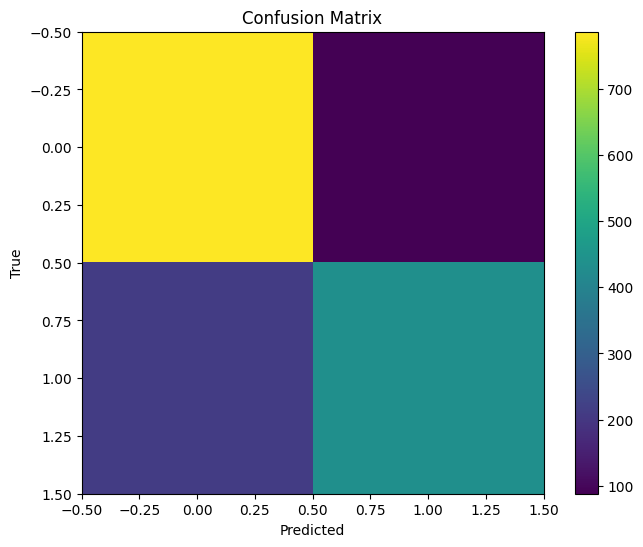

In [27]:
import matplotlib.pyplot as plt
cn = confusion_matrix( y_valid, lr_preds)
plt.figure(figsize=(8, 6))
plt.imshow(cn)
plt.title('Confusion Matrix')
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_valid, lr_preds))

              precision    recall  f1-score   support

           0       0.79      0.90      0.84       874
           1       0.83      0.67      0.74       649

    accuracy                           0.80      1523
   macro avg       0.81      0.79      0.79      1523
weighted avg       0.81      0.80      0.80      1523



Recall = 0.67 ⚠️

This is the IMPORTANT part.

Meaning:

Out of all REAL disaster tweets,
the model only detects:

67%

It MISSES:

33%

of disasters.

In [29]:
wrong = train.iloc[:len(y_valid)]
wrong['pred'] = svm_preds
mistakes = wrong[wrong['target'] != wrong['pred']]

/tmp/ipykernel_743/4214297863.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wrong['pred'] = svm_preds


In [30]:
mistakes[['text', 'target', 'pred']].head(10)

,text,target,pred
0,Our Deeds are the Reason of this #earthquake M...,1,0
1,Forest fire near La Ronge Sask. Canada,1,0
3,"13,000 people receive #wildfires evacuation or...",1,0
5,#RockyFire Update => California Hwy. 20 closed...,1,0
6,#flood #disaster Heavy rain causes flash flood...,1,0
7,I'm on top of the hill and I can see a fire in...,1,0
8,There's an emergency evacuation happening now ...,1,0
12,#raining #flooding #Florida #TampaBay #Tampa 1...,1,0
13,#Flood in Bago Myanmar #We arrived Bago,1,0
14,Damage to school bus on 80 in multi car crash ...,1,0


In [31]:
import re
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))

lemmatizer = WordNetLemmatizer()

def clean_text_advanced(text):

    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove mentions
    text = re.sub(r'@\w+', '', text)

    # keep hashtag words
    text = re.sub(r'#', '', text)

    # remove html entities
    text = re.sub(r'&\w+;', '', text)

    # remove numbers
    text = re.sub(r'\d+', '', text)

    # remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # tokenize
    words = text.split()

    # remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(words)

train['clean_text'] = train['text'].apply(
    clean_text_advanced
)

test['clean_text'] = test['text'].apply(
    clean_text_advanced
)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [32]:
train['tweet_length'] = train['text'].apply(len)

train['word_count'] = train['text'].apply(
    lambda x: len(x.split())
)

train['caps_count'] = train['text'].apply(
    lambda x: sum(1 for c in x if c.isupper())
)

train['exclamation_count'] = train['text'].apply(
    lambda x: x.count('!')
)

train['question_count'] = train['text'].apply(
    lambda x: x.count('?')
)

train['hashtag_count'] = train['text'].apply(
    lambda x: x.count('#')
)

train['mention_count'] = train['text'].apply(
    lambda x: x.count('@')
)

train['url_count'] = train['text'].apply(
    lambda x: x.count('http')
)

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,3),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    stop_words='english'
)

In [34]:
X = vectorizer.fit_transform(
    train['clean_text']
)

y = train['target']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [36]:
from sklearn.svm import LinearSVC

model = LinearSVC(
    class_weight='balanced',
    C=1.2
)

model.fit(X_train, y_train)

LinearSVC(C=1.2, class_weight='balanced')

In [37]:
preds = model.predict(X_valid)

In [38]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

print(
    "Accuracy:",
    accuracy_score(y_valid, preds)
)

print(
    "F1 Score:",
    f1_score(y_valid, preds)
)

print(
    classification_report(y_valid, preds)
)

Accuracy: 0.7859487852921865
F1 Score: 0.7519025875190258
              precision    recall  f1-score   support

           0       0.81      0.81      0.81       869
           1       0.75      0.76      0.75       654

    accuracy                           0.79      1523
   macro avg       0.78      0.78      0.78      1523
weighted avg       0.79      0.79      0.79      1523



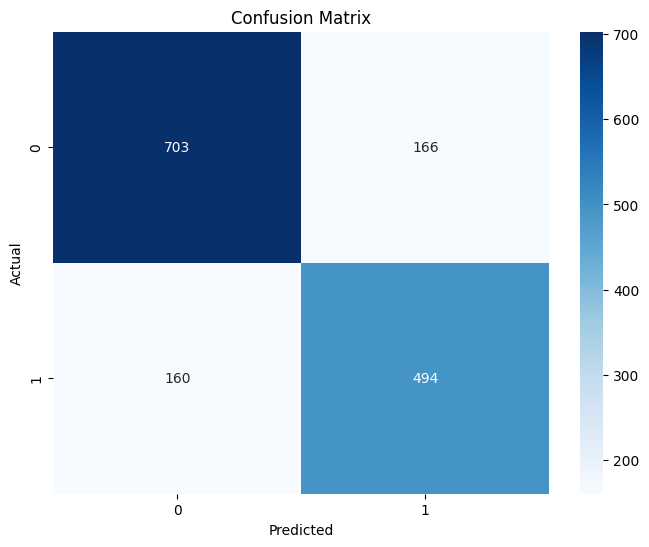

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_valid, preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [40]:
valid_df = train.iloc[y_valid.index].copy()

valid_df['pred'] = preds

mistakes = valid_df[
    valid_df['target'] != valid_df['pred']
]

mistakes[['text', 'target', 'pred']].head(20)

,text,target,pred
4863,@TheEconomist Step one: get that mass murderer...,0,1
6837,Hollywood Movie About Trapped Miners Released ...,1,0
6167,Thu Aug 06 2015 01:20:32 GMT+0000 (UTC)\n#mill...,1,0
2905,I can't drown my demons they know how to swim,1,0
1318,@nagel_ashley @Vicken52 @BasedLaRock @goonc1ty...,0,1
1358,if firefighters acted like cops they'd drive a...,0,1
5303,@DrAtomic420 where did you get that pic from w...,0,1
2685,Ignition Knock (Detonation) Sensor-Senso Stand...,0,1
6006,I agree with certain cultural appropriation th...,1,0
3441,The Dress Memes Have Officially Exploded On Th...,1,0


In [41]:
!pip install transformers datasets accelerate

In [42]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

import torch

In [43]:
train = train.sample(2000)
tokenizer = AutoTokenizer.from_pretrained(
    'bert-base-uncased'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [44]:
train_encodings = tokenizer(
    train['text'].tolist(),
    truncation=True,
    padding=True,
    max_length=64
)

In [45]:
class DisasterDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [46]:
dataset = DisasterDataset(
    train_encodings,
    train['target'].tolist()
)

In [47]:
model = AutoModelForSequenceClassification.from_pretrained(
    'bert-base-uncased',
    num_labels=2)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [48]:
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=1,
    per_device_train_batch_size=8,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [49]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset
)

In [50]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.5663585205078125, metrics={'train_runtime': 1520.5225, 'train_samples_per_second': 1.315, 'train_steps_per_second': 0.164, 'total_flos': 65777763840000.0, 'train_loss': 0.5663585205078125, 'epoch': 1.0})

In [54]:
model.save_pretrained('./disaster_model')

tokenizer.save_pretrained('./disaster_model')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./disaster_model/tokenizer_config.json', './disaster_model/tokenizer.json')

In [55]:
def predict_disaster(text):
   inputs = tokenizer(
        text,
        truncation=True,
        padding=True,
        max_length=64,
        return_tensors='pt')
   outputs = model(**inputs)
   probs = torch.nn.functional.softmax(outputs.logits, dim=-1)
   prediction = torch.argmax(probs).item()
   confidence = probs[0][prediction].item()

   return prediction, confidence


In [56]:
tweet = "Massive flood destroyed homes"

pred, conf = predict_disaster(tweet)

print(pred)
print(conf)
if pred == 1:
  print("Disaster")
else:
  print("Not a disaster")

1
0.9095276594161987
Disaster


In [57]:
tweet = "i love watching movies"

pred, conf = predict_disaster(tweet)

print(pred)
print(conf)

0
0.7887760400772095


In [62]:
from IPython.display import HTML, display
import torch
import time

# =====================================================
# 🎨 BEAUTIFUL HEADER UI
# =====================================================

display(HTML("""
<div style="
background: linear-gradient(135deg,#141E30,#243B55);
padding:35px;
border-radius:20px;
text-align:center;
color:white;
font-family:Arial;
box-shadow:0px 0px 20px rgba(0,0,0,0.4);
margin-bottom:20px;
">

<h1 style="font-size:42px; color:#ddd;">
🚨 Disaster Tweet Detector AI
</h1>

<p style="font-size:18px;color:#ddd;">
Analyze tweets using Artificial Intelligence
and detect whether they describe a real disaster.
</p>

</div>
"""))

# =====================================================
# 🧪 SAMPLE TWEETS
# =====================================================

samples = [
    "Earthquake damaged many buildings",
    "Massive wildfire spreading rapidly",
    "Flood water entered the city",
    "I love pizza 🍕",
    "This song is fire 🔥"
]

print("\n🧪 SAMPLE TWEETS")
print("=" * 60)

for i, s in enumerate(samples, 1):

    print(f"{i}. {s}")

# =====================================================
# 🤖 MODEL PREDICTION FUNCTION
# =====================================================

model.eval()

def predict_tweet(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    )

    with torch.no_grad():

        outputs = model(**inputs)

    probs = torch.softmax(
        outputs.logits,
        dim=1
    )

    pred = torch.argmax(probs).item()

    confidence = probs[0][pred].item()

    disaster_prob = probs[0][1].item()

    non_disaster_prob = probs[0][0].item()

    return pred, confidence, disaster_prob, non_disaster_prob

# =====================================================
# 📊 CONFIDENCE BAR FUNCTION
# =====================================================

def confidence_bar(value):

    bars = int(value * 20)

    return "█" * bars + "-" * (20 - bars)

# =====================================================
# ✍️ USER INPUT
# =====================================================

print("\n" + "=" * 60)

tweet = input("✍️ Enter a Tweet: ")

# =====================================================
# ⏳ LOADING EFFECT
# =====================================================

print("\n⏳ AI is analyzing the tweet...")

time.sleep(1)

# =====================================================
# 🚀 PREDICTION
# =====================================================

pred, conf, disaster_p, non_disaster_p = predict_tweet(tweet)

# =====================================================
# 📢 RESULT SECTION
# =====================================================

print("\n📢 AI PREDICTION")
print("=" * 60)

if pred == 1:

    print("🚨 RESULT: DISASTER TWEET")

else:

    print("✅ RESULT: NON-DISASTER TWEET")

print(f"\n🎯 Confidence Score: {conf:.2%}")

# =====================================================
# 📈 CONFIDENCE VISUALIZATION
# =====================================================

print("\n📈 Confidence Bar")
print("-" * 60)

print(confidence_bar(conf))

# =====================================================
# 📊 PROBABILITY BREAKDOWN
# =====================================================

print("\n📊 Prediction Breakdown")
print("-" * 60)

print(f"🚨 Disaster Probability:      {disaster_p:.2%}")

print(f"✅ Non-Disaster Probability:  {non_disaster_p:.2%}")

# =====================================================
# 🧠 TWEET ANALYTICS
# =====================================================

words = len(tweet.split())

chars = len(tweet)

hashtags = tweet.count("#")

mentions = tweet.count("@")

uppercase = sum(1 for c in tweet if c.isupper())




🧪 SAMPLE TWEETS
1. Earthquake damaged many buildings
2. Massive wildfire spreading rapidly
3. Flood water entered the city
4. I love pizza 🍕
5. This song is fire 🔥

✍️ Enter a Tweet: This song is fire 🔥

⏳ AI is analyzing the tweet...

📢 AI PREDICTION
✅ RESULT: NON-DISASTER TWEET

🎯 Confidence Score: 90.60%

📈 Confidence Bar
------------------------------------------------------------
██████████████████--

📊 Prediction Breakdown
------------------------------------------------------------
🚨 Disaster Probability:      9.40%
✅ Non-Disaster Probability:  90.60%
